<a href="https://colab.research.google.com/github/RiccoFlores/100-Days-Of-ML-Code/blob/master/NB7_Data_Normalization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Transformation: Data Normalization

The Titanic Dataset [[Documentation](https://www.kaggle.com/c/titanic)] is one of the most famous dataset at Kaggle. The main goal is to create a model that predicts which passengers survived the Titanic shipwreck.

The features in the dataset are:
* PassengerId: Identifier for each passenger (unique).
* Survived: Survival (0 = No, 1 = Yes).
* Pclass: Ticket class (1 = 1st, 2 = 2nd and 3 = 3rd).
* Name: Name of the passenger.
* Sex: Sex of the passenger.
* Age: Age in years.
* SibSp: Number of siblings/spouses aboard the Titanic.
* Parch: Number of parents/children aboard the Titanic.
* Ticket: Ticker number.
* Fare: Passenger fare.
* Cabin: Cabin number.
* Embarked: Port of embarkation (C = Cherboug, Q = Queenstown, S = Southampton).

The main objective of this notebook is to explore the scaling techniques.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
import scipy.stats as stats
#from stats import boxcox
from scipy.stats import boxcox

In [ ]:
# Data Loading
#titanic = pd.read_csv("titanic.csv")
titanic = sns.load_dataset("titanic")
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [ ]:
# Data Description
titanic.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
titanic.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


In [ ]:
# Missing Values
100*titanic.isnull().sum()/titanic.shape[0]

,0
survived,0.000000
pclass,0.000000
sex,0.000000
age,19.865320
sibsp,0.000000
parch,0.000000
fare,0.000000
embarked,0.224467
class,0.000000
who,0.000000


In [ ]:
# Age and Fare
titanic_sample = titanic[['age', 'fare']].copy()
titanic_sample.head()

,age,fare
0,22.0,7.2500
1,38.0,71.2833
2,26.0,7.9250
3,35.0,53.1000
4,35.0,8.0500


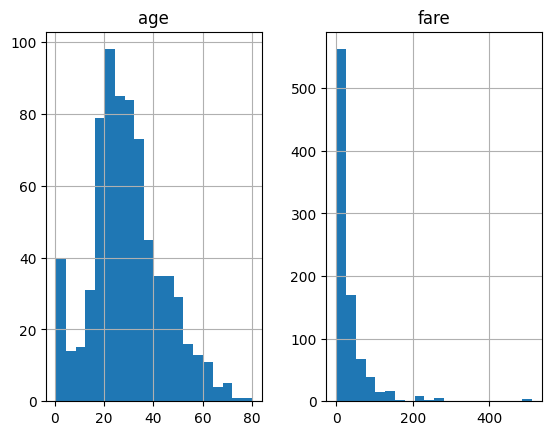

In [ ]:
# Data Distribution
titanic_sample.hist(bins = 20)
#titanic.hist()
plt.show()

In [ ]:
# Deleting rows with NA
titanic_sample.dropna(inplace = True)

In [ ]:
# Missing Values
titanic_sample.isnull().sum()

,0
age,0
fare,0


In [ ]:
titanic_sample.shape

(714, 2)

### 1. Min-Max Normalization

In [ ]:
# Steps to Normalize a Variable:
# 1. Create the object
# 2. Fit the data.
# 3. Transform the data

# Object Creation
scaler = MinMaxScaler()
#scaler = MinMaxScaler(feature_range = (-1,1))

# Data Fitting
scaler.fit(titanic_sample)

# Data Transformation
titanic_sample_minmax = scaler.transform(titanic_sample)

In [ ]:
titanic_sample.head()

,age,fare
0,22.0,7.2500
1,38.0,71.2833
2,26.0,7.9250
3,35.0,53.1000
4,35.0,8.0500


In [ ]:
# np.array instead pd.dataframe
titanic_sample_minmax

array([[0.27117366, 0.01415106],
       [0.4722292 , 0.13913574],
       [0.32143755, 0.01546857],
       ...,
       [0.23347575, 0.0585561 ],
       [0.32143755, 0.0585561 ],
       [0.39683338, 0.01512699]])

In [ ]:
minmax_df = pd.DataFrame(data=titanic_sample_minmax,
                         columns=['age','fare'])
minmax_df.head()

,age,fare
0,0.271174,0.014151
1,0.472229,0.139136
2,0.321438,0.015469
3,0.434531,0.103644
4,0.434531,0.015713


In [ ]:
minmax_df.describe()

,age,fare
count,714.000000,714.000000
mean,0.367921,0.067719
std,0.182540,0.103291
min,0.000000,0.000000
25%,0.247612,0.015713
50%,0.346569,0.030726
75%,0.472229,0.065144
max,1.000000,1.000000


In [ ]:
# Main Statistical Variables
print("Mean: \n", titanic_sample_minmax.mean(axis = 0))
print("Std Dev: \n", titanic_sample_minmax.std(axis = 0))
print("Median: \n", np.median(titanic_sample_minmax, axis = 0))
print("Min: \n", titanic_sample_minmax.min(axis = 0))
print("Max: \n", titanic_sample_minmax.max(axis = 0))

Mean: 
 [0.36792055 0.06771918]
Std Dev: 
 [0.18241168 0.10321851]
Median: 
 [0.34656949 0.03072575]
Min: 
 [0. 0.]
Max: 
 [1. 1.]


In [ ]:
def plots(df1, df2, var_name):

    plt.figure(figsize = (15, 5))

    plt.subplot(1, 2, 1)
    plt.hist(df1, bins = 20)
    plt.title("Original Data")
    plt.xlabel(var_name)
    plt.ylabel("Frequency")

    plt.subplot(1, 2, 2)
    plt.hist(df2, bins = 20)
    plt.title("Normalized Data")
    plt.xlabel(var_name)
    plt.ylabel("Frequency")
    plt.show()

MinMax Normalization: Age


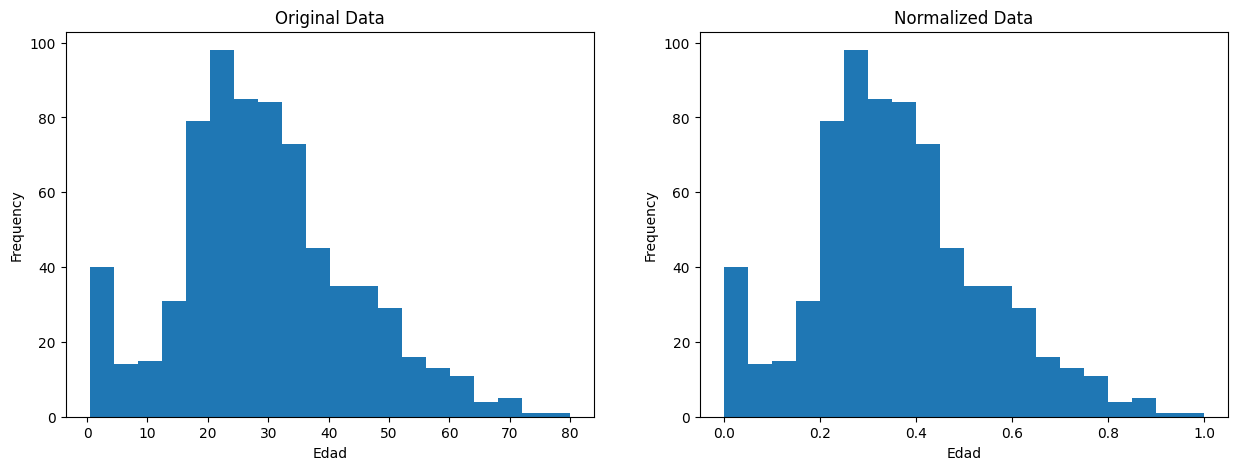

MinMax Normalization: Fare


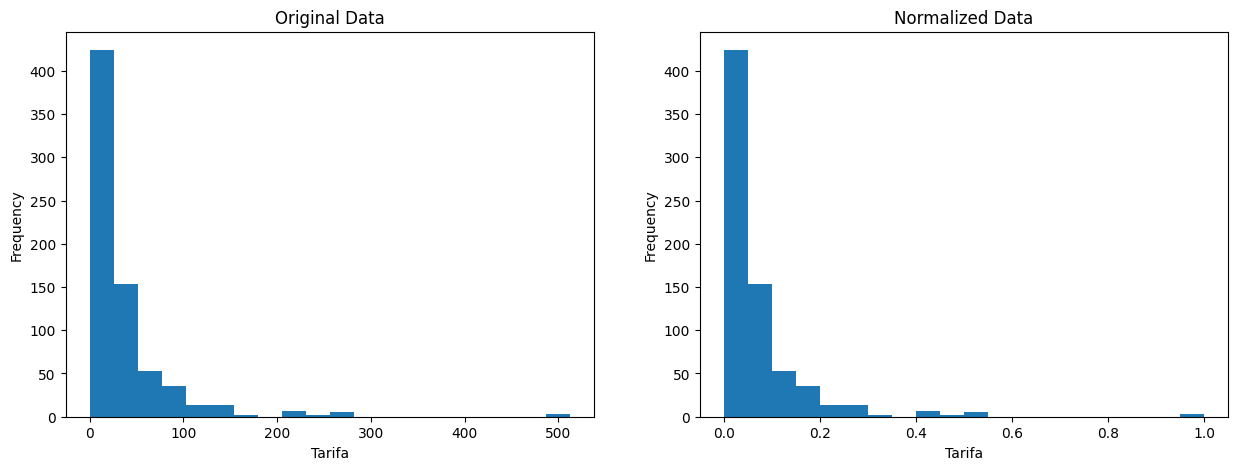

In [ ]:
# Plotting Data
print("MinMax Normalization: Age")
plots(titanic_sample["age"], minmax_df['age'], "Edad")

# Plotting Data
print("MinMax Normalization: Fare")
plots(titanic_sample["fare"], minmax_df['fare'], "Tarifa")

## 2. Z-Score Normalization

In [ ]:
scaler = StandardScaler()
scaler.fit(titanic_sample)
titanic_sample_scaled = scaler.transform(titanic_sample)
#titanic_sample_scaled = scaler.fit_transform(titanic_sample)

In [ ]:
titanic_sample_scaled

array([[-0.53037664, -0.51897787],
       [ 0.57183099,  0.69189675],
       [-0.25482473, -0.50621356],
       ...,
       [-0.73704057, -0.08877362],
       [-0.25482473, -0.08877362],
       [ 0.15850313, -0.50952283]])

In [ ]:
# Main Statistical Variables
print("Mean: \n", titanic_sample_scaled.mean(axis = 0))
print("Std Dev: \n", titanic_sample_scaled.std(axis = 0))
print("Median: \n", np.median(titanic_sample_scaled, axis = 0))
print("Min: \n", titanic_sample_scaled.min(axis = 0))
print("Max: \n", titanic_sample_scaled.max(axis = 0))

Mean: 
 [ 2.33862105e-16 -5.97094736e-17]
Std Dev: 
 [1. 1.]
Median: 
 [-0.11704878 -0.35839917]
Min: 
 [-2.01697919 -0.65607592]
Max: 
 [3.46512604 9.03210855]


Z-score Normalization: Age


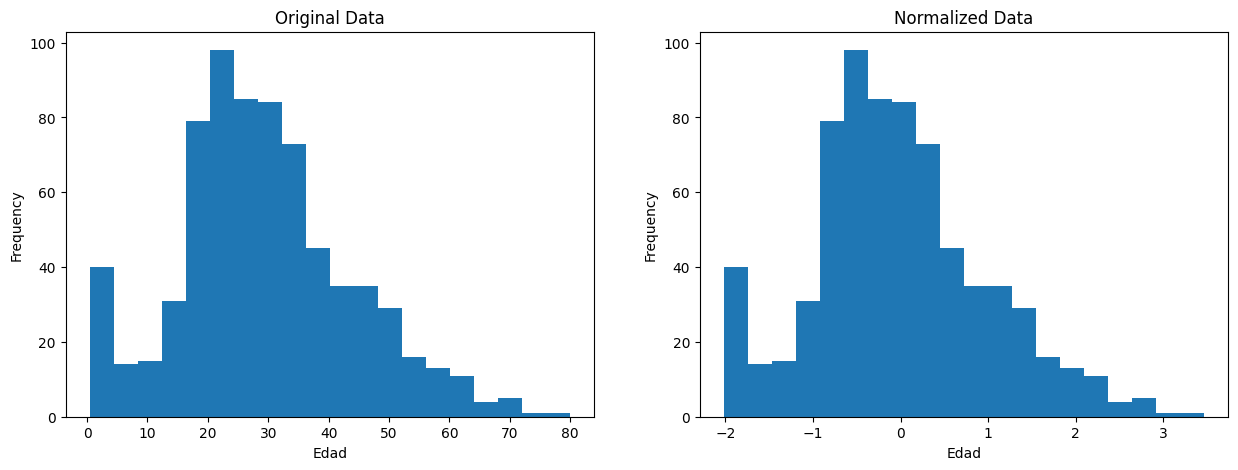

Z-score Normalization: Fare


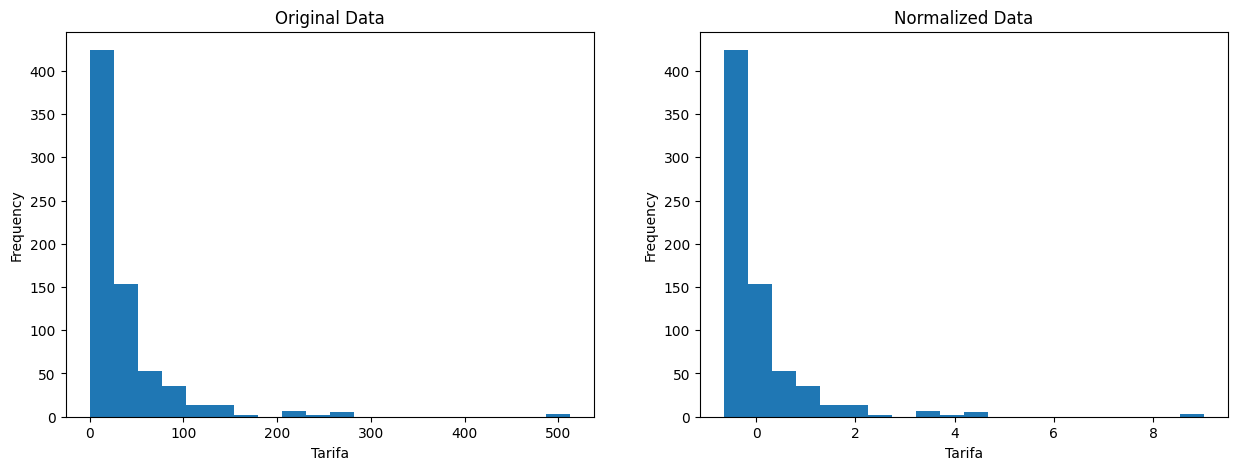

In [ ]:
# Plotting Data
print("Z-score Normalization: Age")
plots(titanic_sample["age"], titanic_sample_scaled[:,0], "Edad")

# Plotting Data
print("Z-score Normalization: Fare")
plots(titanic_sample["fare"], titanic_sample_scaled[:,1], "Tarifa")

## 3. Robust (Median and IQR)

In [ ]:
scaler = RobustScaler()
scaler.fit(titanic_sample)
titanic_sample_robust = scaler.transform(titanic_sample)

In [ ]:
# Main Statistical Variables
print("Mean: \n", titanic_sample_robust.mean(axis = 0))
print("Std Dev: \n", titanic_sample_robust.std(axis = 0))
print("Median: \n", np.median(titanic_sample_robust, axis = 0))
print("Min: \n", titanic_sample_robust.min(axis = 0))
print("Max: \n", titanic_sample_robust.max(axis = 0))

Mean: 
 [0.09505553 0.74838357]
Std Dev: 
 [0.81210188 2.08812867]
Median: 
 [0. 0.]
Min: 
 [-1.54293706 -0.62158736]
Max: 
 [ 2.90909091 19.60858835]


In [ ]:
robust_df = pd.DataFrame(data=titanic_sample_robust,
                         columns=['age','fare'])
robust_df.head()

,age,fare
0,-0.335664,-0.335309
1,0.559441,2.193153
2,-0.111888,-0.308655
3,0.391608,1.475155
4,0.391608,-0.303720


In [ ]:
robust_df.describe()

,age,fare
count,714.000000,714.000000
mean,0.095056,0.748384
std,0.812671,2.089592
min,-1.542937,-0.621587
25%,-0.440559,-0.303720
50%,0.000000,0.000000
75%,0.559441,0.696280
max,2.909091,19.608588


In [ ]:
#Q3 - Q1
#(0.559441)-(-0.440559)
(0.696280)-(-0.303720)

1.0

Robust Normalization: Age


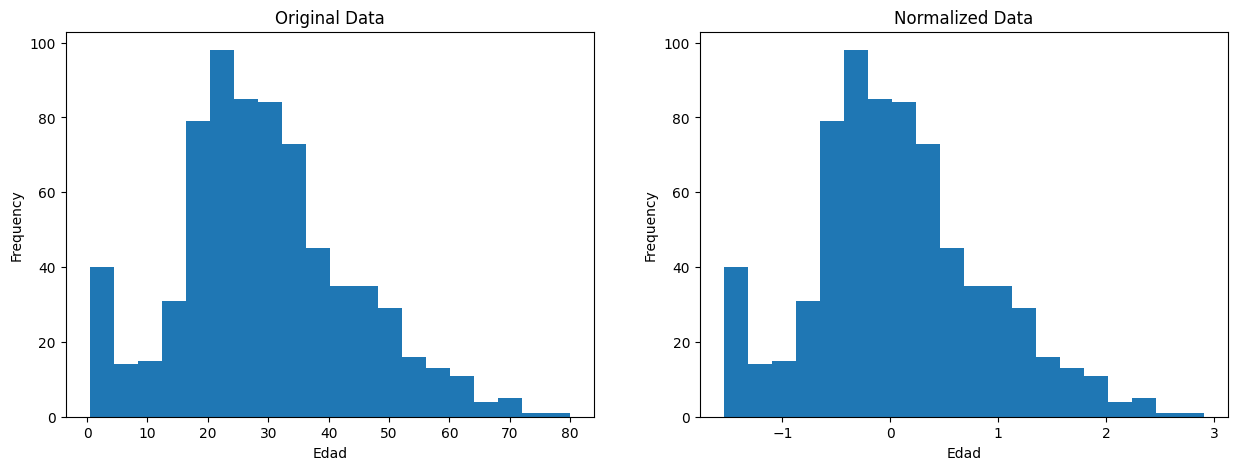

Robust Normalization: Fare


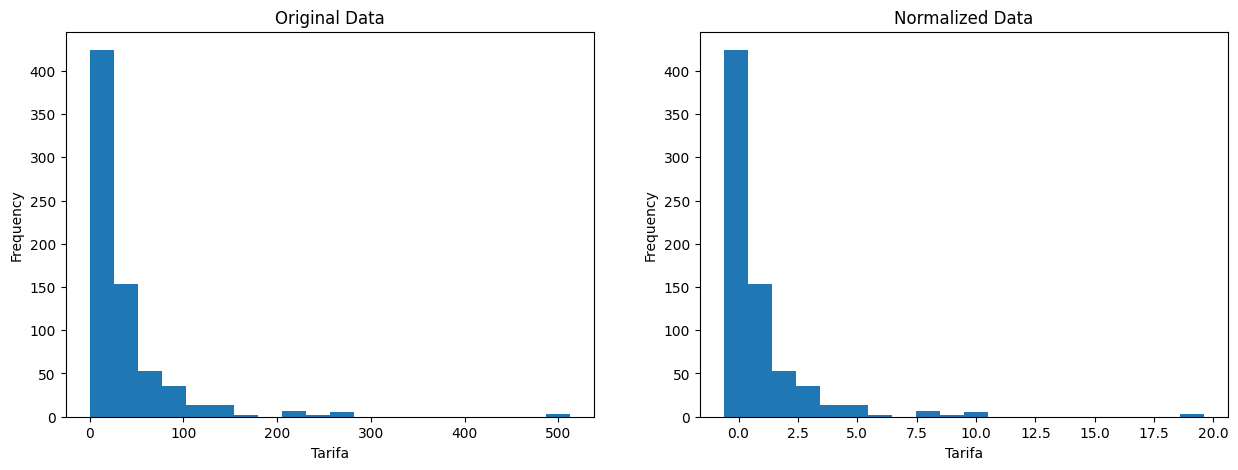

In [ ]:
# Plotting Data
print("Robust Normalization: Age")
plots(titanic_sample["age"], titanic_sample_robust[:,0], "Edad")

# Plotting Data
print("Robust Normalization: Fare")
plots(titanic_sample["fare"], titanic_sample_robust[:,1], "Tarifa")

## 4.  Transformationes: Log y BoxCox

In [ ]:
titanic_sample.head()

,age,fare,fare_1,fare_log
0,22.0,7.2500,8.2500,2.110213
1,38.0,71.2833,72.2833,4.280593
2,26.0,7.9250,8.9250,2.188856
3,35.0,53.1000,54.1000,3.990834
4,35.0,8.0500,9.0500,2.202765


In [ ]:
# Logarithmic Transformation
titanic_sample["fare_1"] = titanic_sample["fare"] + 1
titanic_sample["fare_log"] = np.log(titanic_sample.fare_1)

Log Normalization: Fare


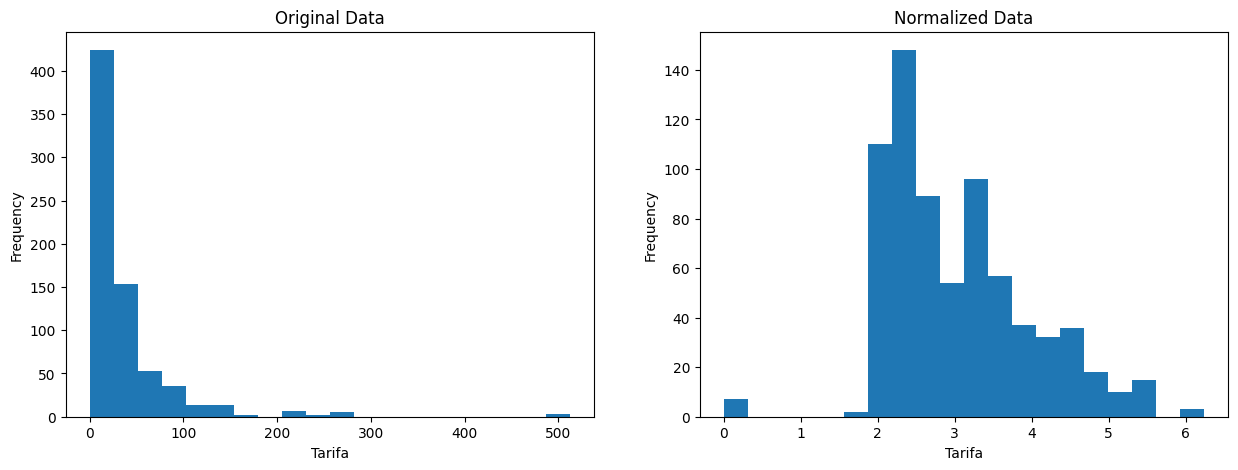

In [ ]:
# Plotting Data
print("Log Normalization: Fare")
plots(titanic_sample.fare, titanic_sample.fare_log, "Tarifa")

In [ ]:
# Square Transformation
titanic_sample["Age_Squared"] = titanic_sample.Age ** 2
titanic_sample.head()

In [ ]:
# Plotting Data
print("Square Transformation: Age")
plots(titanic_sample.Age, titanic_sample.Age_Squared, "Edad")

In [ ]:
# BoxCox Transformation
titanic_sample['age_boxcox'], param = stats.boxcox(titanic_sample["age"])
print("Optimal lambda: ", param)

Optimal lambda:  0.762789049635355


Robust Normalization: Age


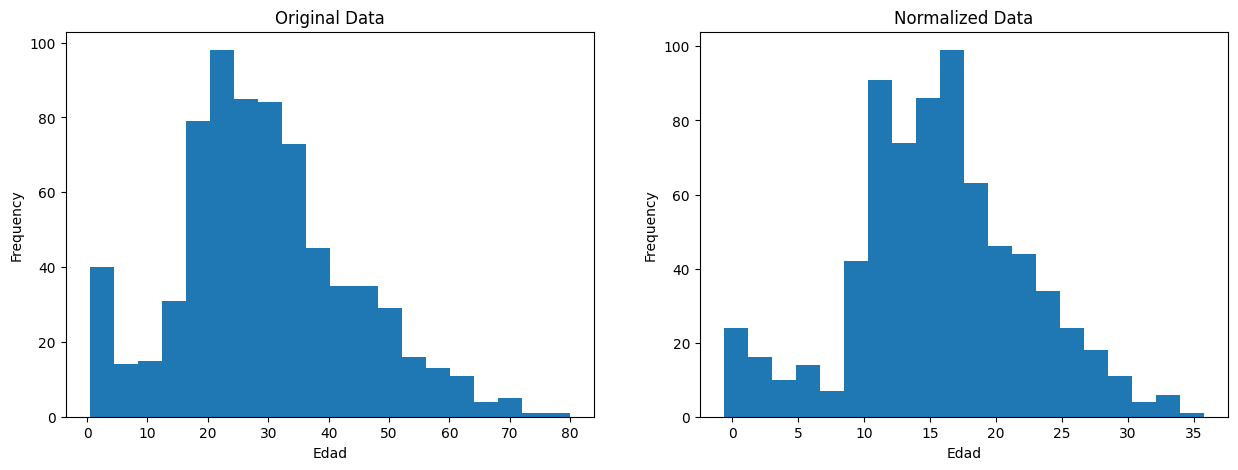

In [ ]:
# Plotting Data
print("Robust Normalization: Age")
plots(titanic_sample.age, titanic_sample.age_boxcox, "Edad")